In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc

rc('font', size=16)

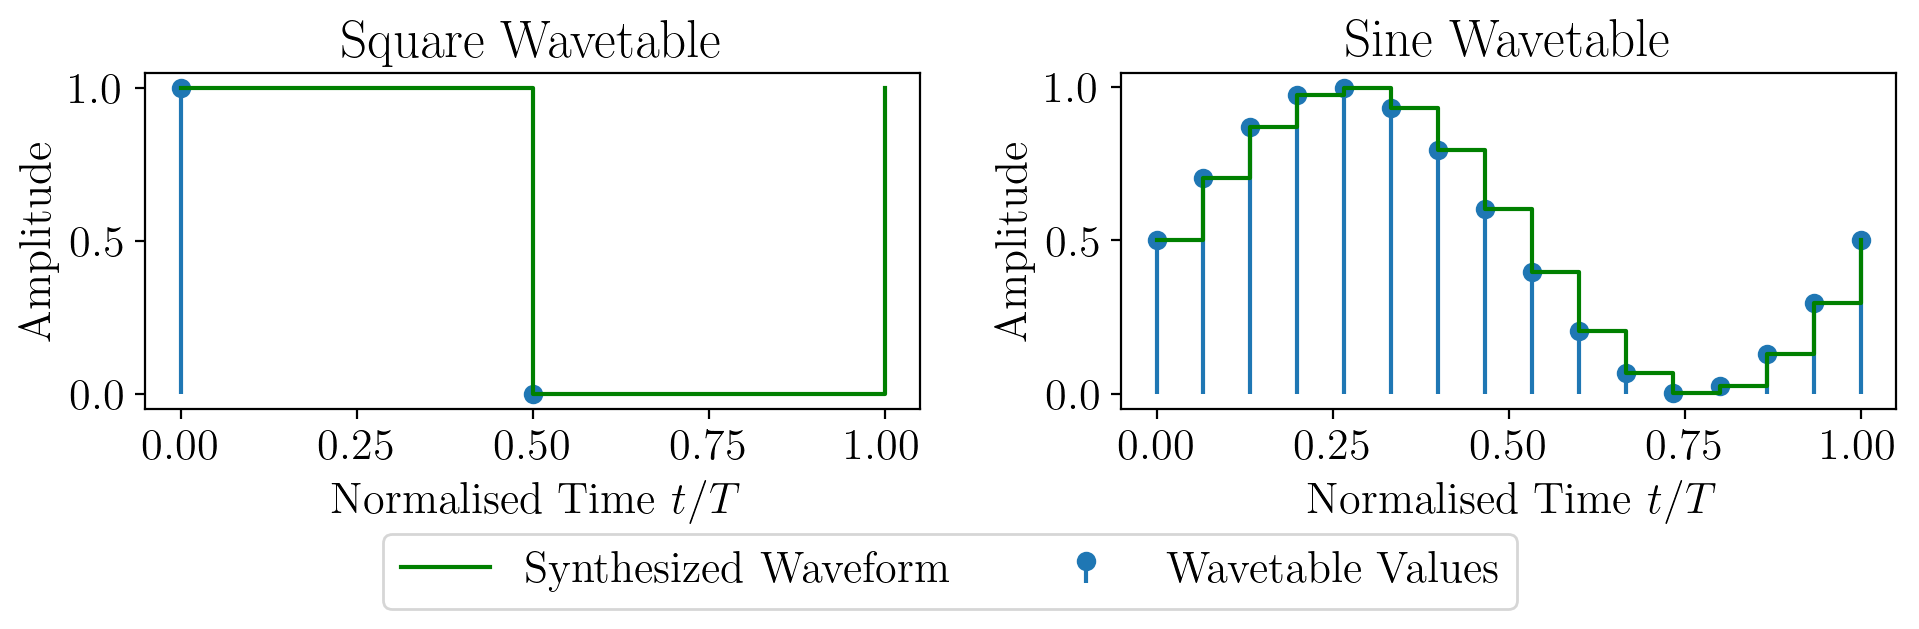

In [6]:

t_smp = np.linspace(0, 1, 16)

wt_sine_smp = 0.5 * np.sin(2 * np.pi * t_smp) + 0.5

t = np.linspace(0, 1, 1000)
wt_sine = 0.5*np.sin(2 * np.pi * t) + 0.5
wt_square = np.where((t % 1) < 0.5, 1, 0)

figure, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))

ax1.stem([0, 0.5], [1, 0], basefmt=' ', label='Wavetable Values')
ax1.step([0, 0.5, 1], [1,0,1], 'g', where='post', label='Synthesized Waveform')
ax2.stem(t_smp, wt_sine_smp, basefmt=' ')
ax2.step(t_smp, wt_sine_smp, 'g', where='post')
# figure.setp(bl, visible=False)
# figure.setp(sl, visible=False)
ax1.set_title('Square Wavetable')
ax1.set_xlabel('Normalised Time $t/T$')
ax1.set_ylabel('Amplitude')
ax2.set_title('Sine Wavetable')
ax2.set_xlabel('Normalised Time $t/T$')
ax2.set_ylabel('Amplitude')
figure.legend(loc='lower center', bbox_to_anchor=(0.5, -0.1), ncol=2)
figure.tight_layout()
figure.savefig('../docs/latex/images/wavetable_example.png', bbox_inches='tight')

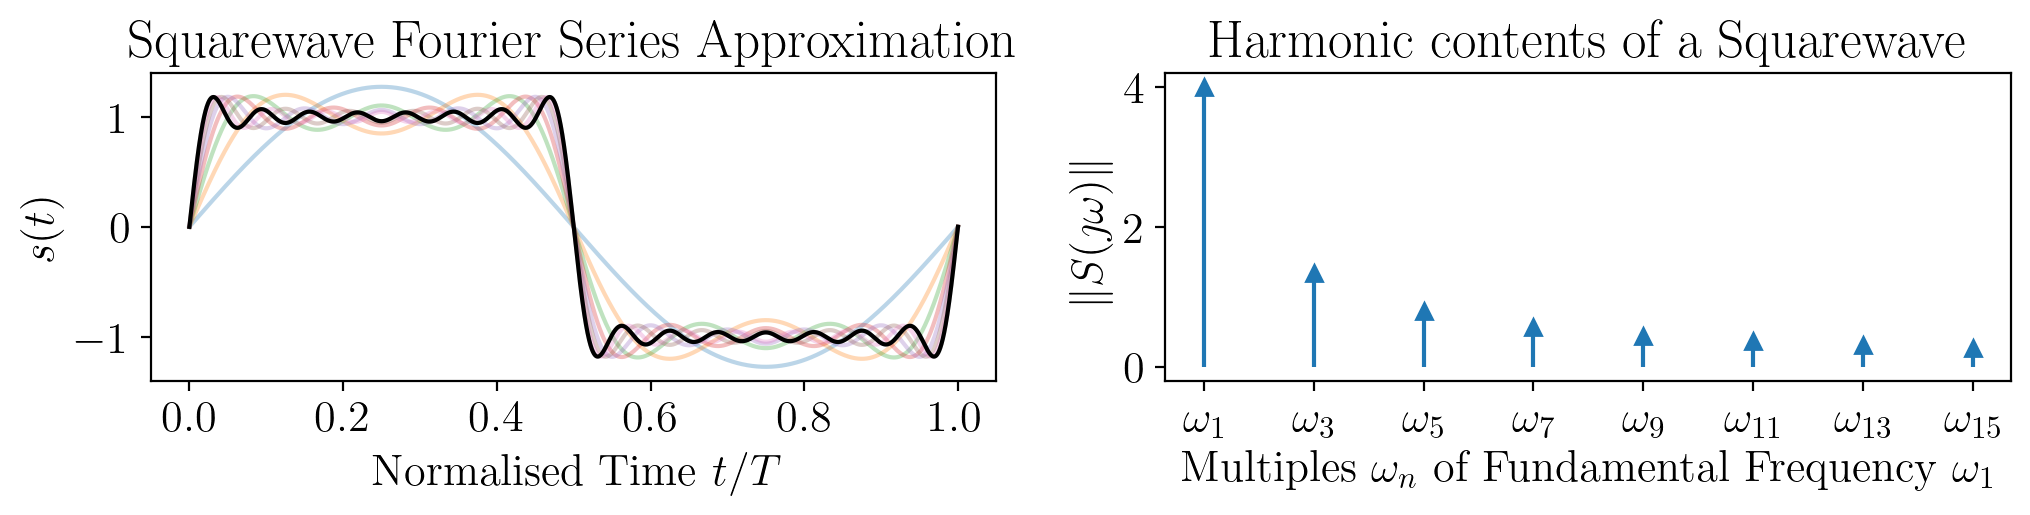

In [7]:
T = 1
N = 15
t = np.linspace(0, T, 5000)

sines = [(4 / (n * np.pi)) * np.sin(n * 2 * np.pi * t / T) for n in range(1, N + 1, 2)]

figure, (ax_time, ax_freq) = plt.subplots(1,2, figsize=(12,2))

# gradually build square wave from Fourier series
square_wave_approx = np.zeros_like(t)
for n, sine in enumerate(sines, start=1):
	square_wave_approx += sine
	ax_time.plot(t, square_wave_approx, label=f'N={2*n-1}', alpha=0.3)
ax_time.plot(t, square_wave_approx, label=f'N={2*n-1}', color='black')
ax_time.set_title('Squarewave Fourier Series Approximation')
ax_time.set_xlabel('Normalised Time $t/T$')
ax_time.set_ylabel('$s(t)$')

for n in range(1, N + 1, 2):
	ax_freq.stem(n, 4/n, markerfmt='^')

ax_freq.set_title('Harmonic contents of a Squarewave')
ax_freq.set_xlabel('Multiples $\\omega_n$ of Fundamental Frequency $\\omega_1$')
ax_freq.set_ylabel('$\\|S(\\jmath\\omega)\\|$')
xticks = [f'$\\omega_{{{n}}}$' for n in range(1, N + 1, 2)]

ax_freq.set_xticks(list(range(1, N + 1, 2)), labels=xticks)
figure.savefig('../docs/latex/images/square_wave_fourier_series.png', bbox_inches='tight')


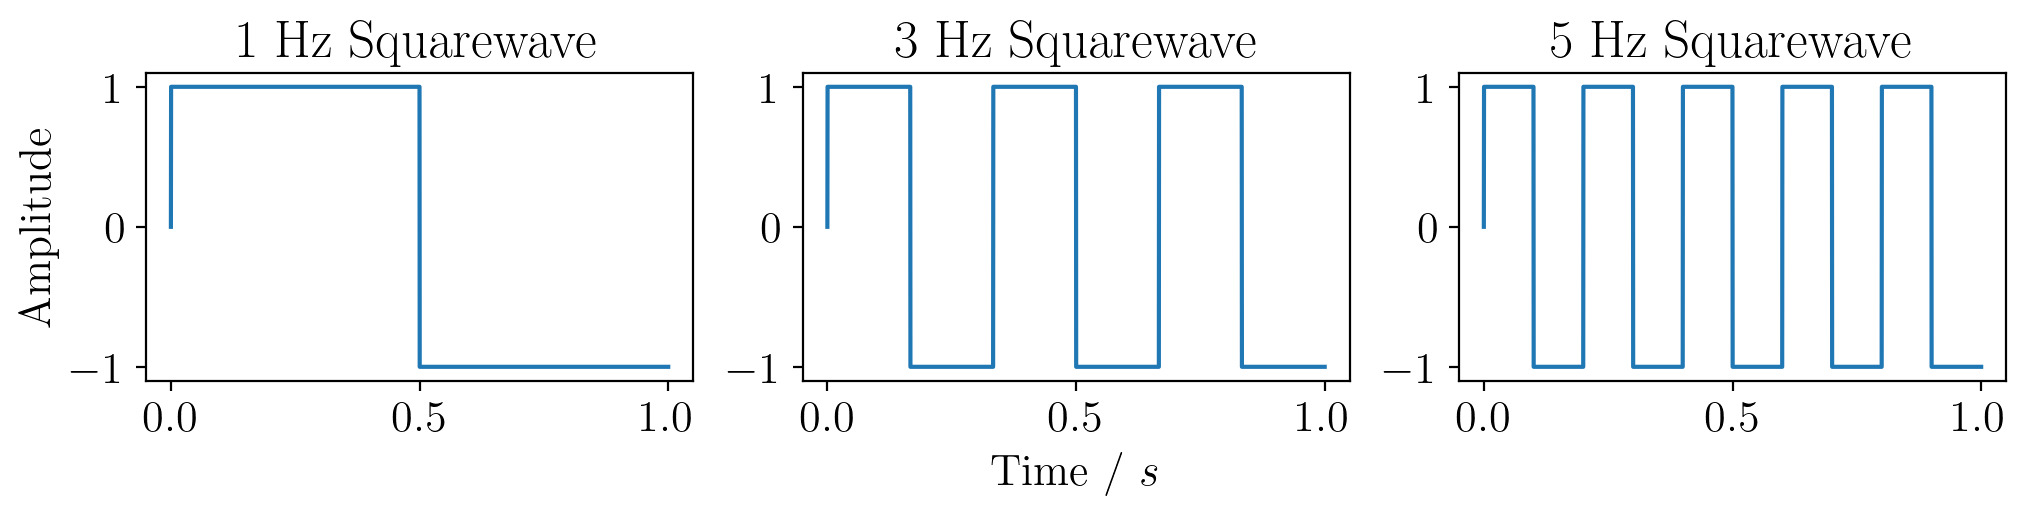

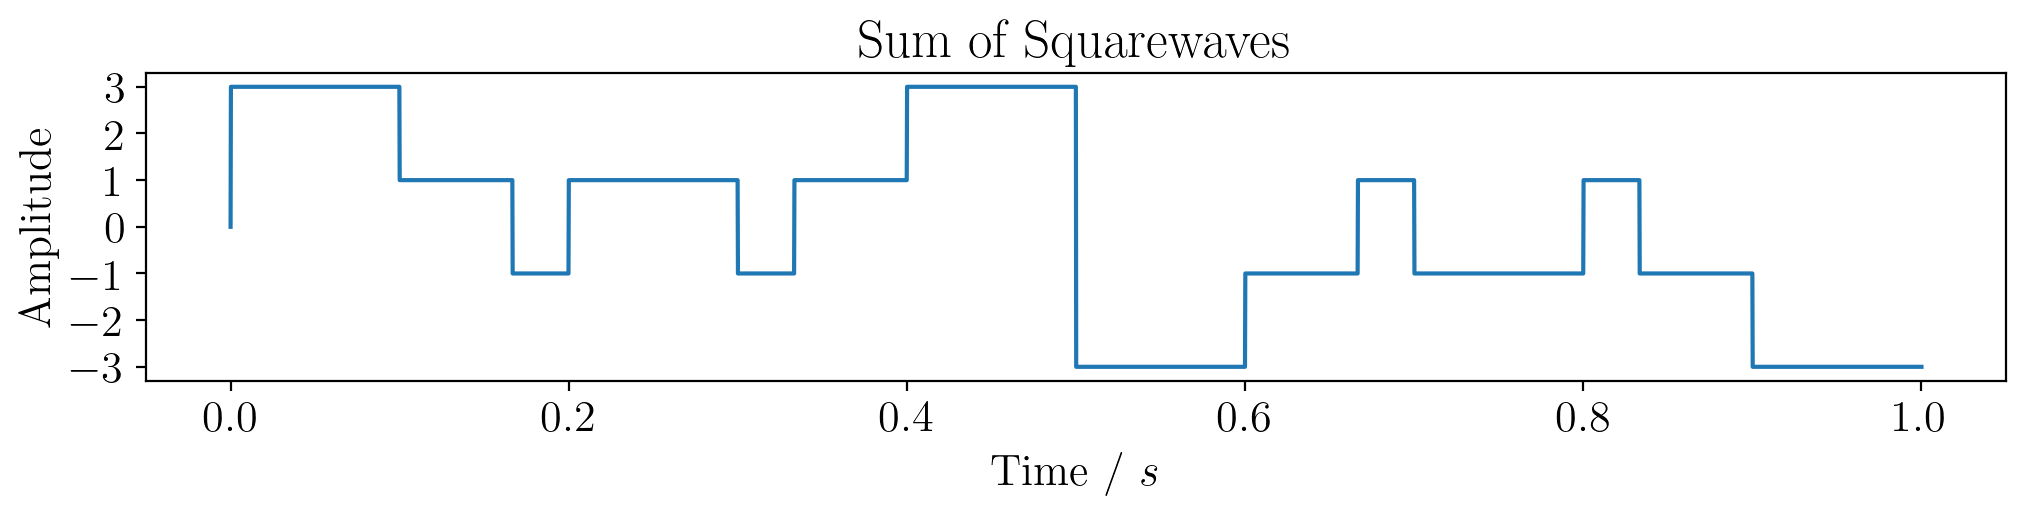

In [8]:
# generate multiple square waves with different frequencies
sqs = [np.sign(np.sin(2 * np.pi * f * t)) for f in [1, 3, 5]]
sq = sum(sqs)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 2))

for ax, i in zip((ax1, ax2, ax3), range(3)): 
	ax.plot(t, sqs[i])
	ax.set_title(f'{2*i+1} Hz Squarewave')
	ax.set_yticks([-1, 0, 1])

ax1.set_ylabel('Amplitude')
ax2.set_xlabel('Time / $s$')
fig.savefig('../docs/latex/images/multiple_squarewaves.png', bbox_inches='tight')	

fig, ax = plt.subplots(figsize=(12, 2))
ax.plot(t, sq)
ax.set_title('Sum of Squarewaves')
ax.set_ylabel('Amplitude')
ax.set_xlabel('Time / $s$')
ax.set_yticks(range(-3, 4))
fig.savefig('../docs/latex/images/sum_of_squarewaves.png', bbox_inches='tight')